# NHL: предсказать успешность команды в следующем сезоне

**Тестовое задание • 100 баллов**

Вы аналитик, которому после окончания сезона нужно оценить перспективы команды
на следующий год. Соберите таблицу с учебного сайта
[Scrape This Site - Hockey Teams](https://www.scrapethissite.com/pages/forms/),
изучите данные и постройте модель классификации.
В работе оцениваются корректность исследования и обоснованность решений.

Ориентир времени: 6-10 часов (знание хоккея не требуется).
Можно обращаться к документации и пользоваться вспомогательными инструментами.
Укажите, чем пользовались; отвечайте за правильность и понимание сданной работы.
Подтверждайте ответы результатами из своего ноутбука.

## Что сдавать

Выполненный IPynb с видимыми результатами и ответами и исходный `data/hockey_raw.csv` разместите на платформе githib.com.
Укажите имя, дату и использованные источники и инструменты в README.

## Что предсказывает модель

Одна строка признаков описывает команду в сезоне `t`.
`target=1`, если доля побед той же команды в сезоне `t+1` строго выше медианной
доли побед всех команд в сезоне `t+1`. В остальных случаях `target=0`.

Медиану считайте по полной исходной таблице будущего года до отбора пар.
В пары включайте одинаковые названия команды с разницей меток сезонов ровно в один год.
Строки без пары исключайте и учитывайте в описании данных.
Будущий `win_rate` и будущая медиана используются для построения target и анализа
готовых прогнозов. Признаки модели должны быть известны после сезона `t`.

## Схема проверки

Делите данные по году целевого сезона:

| Часть | target_year | Назначение |
|---|---|---|
| train | не позднее 2005 | Подготовка данных и обучение |
| validation | 2006-2008 | Сравнение вариантов и выбор решения |
| test | 2009-2011 | Одна итоговая оценка выбранного решения |

Основная метрика: ROC-AUC по вероятности класса 1.
На итоговом этапе также используйте F1 и accuracy при пороге 0.5.
Финальный test используйте после выбора решения на validation.

## Как оценивается работа

| Область | Баллы |
|---|---:|
| Сбор и понимание данных | 15 |
| Построение задачи и корректность проверки | 20 |
| Исследовательский анализ | 20 |
| Модели и эксперименты | 25 |
| Итоговая оценка и анализ ошибок | 15 |
| Ясность и воспроизводимость | 5 |
| **Всего** | **100** |

Ниже перечислены обязательные этапы работы. Внутри них вы самостоятельно выбираете
исследовательские вопросы, графики, признаки, обработку данных, эксперимент и способ
разбора ошибок. Оценивается качество решений, а не совпадение с эталонным маршрутом.
Сложность метода сама по себе не даёт преимущества. Корректный эксперимент может
получить полный балл и в случае отсутствия улучшения.

## Требования к сбору

Итоговая исходная таблица должна иметь столбцы `team`, `year`, `wins`, `losses`,
`ot_losses`, `win_rate`, `goals_for`, `goals_against`, `goal_diff`.
Самостоятельно исследуйте страницу и определите способ получения всей таблицы.

**Автор:** Мустафаев Ниджат
**Дата:** 07.10.2026
**Использованные источники и инструменты:** …

In [2]:
# Ваши импорты и настройки
import os
from io import StringIO
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
RANDOM_STATE=42

## Раздел 1. Сбор и понимание данных: 15 баллов

### 1.1. Соберите и сохраните данные

Соберите все страницы сайта в одну таблицу с указанными девятью столбцами.
Сохраните исходную выгрузку в `data/hockey_raw.csv`. Укажите URL и дату сбора,
число обработанных страниц и число строк. Покажите, как проверили,
что сбор не ограничился первой страницей и при повторном анализе можно читать CSV.

In [3]:
# 1.1. Ваш код
# Добавьте ячейки при необходимости.
URL = "https://www.scrapethissite.com/pages/forms/"
frames= []
page=1

while True:
    r=requests.get(URL, params={"page_num": page}, timeout=30)
    r.raise_for_status()
    try:
        df_page=pd.read_html(StringIO(r.text))[0]
    except ValueError:
        break
    if df_page.empty:
        break
    frames.append(df_page)
    page+=1

pages_count=len(frames)
raw=pd.concat(frames,ignore_index=True)
raw.columns=["team", "year", "wins", "losses", "ot_losses",
             "win_rate", "goals_for", "goals_against", "goal_diff"]

os.makedirs("data", exist_ok=True)
raw.to_csv("data/hockey_raw.csv", index=False)

print("URL:", URL)
print("Дата сбора:", date.today())
print("Страниц:", pages_count, "| Строк:", len(raw))
print("Годы:", raw["year"].min(), "-", raw["year"].max())
raw.head()



URL: https://www.scrapethissite.com/pages/forms/
Дата сбора: 2026-10-05
Страниц: 24 | Строк: 582
Годы: 1990 - 2011


,team,year,wins,losses,ot_losses,win_rate,goals_for,goals_against,goal_diff
0,Boston Bruins,1990,44,24,NaN,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,NaN,0.388,292,278,14
2,Calgary Flames,1990,46,26,NaN,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,NaN,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,NaN,0.425,273,298,-25


In [4]:
# Проверка, что сбор не ограничился первой страницей, CSV читается заново
check = pd.read_csv("data/hockey_raw.csv")

print("Строк в CSV:", len(check))
print("Строк на одной странице:", len(frames[0]))
print("Страниц собрано:", pages_count)
print("Годы:", check["year"].min(), "-", check["year"].max())
print("Уникальных команд:", check["team"].nunique())
print("Столбцы:", list(check.columns))

Строк в CSV: 582
Строк на одной странице: 25
Страниц собрано: 24
Годы: 1990 - 2011
Уникальных команд: 35
Столбцы: ['team', 'year', 'wins', 'losses', 'ot_losses', 'win_rate', 'goals_for', 'goals_against', 'goal_diff']


**Ответ 1.1:**

Данные собраны с https://www.scrapethissite.com/pages/forms/ , дата сбора: 04.10.2026.
Обработано 24 страницы, получено 582 строки. Исходная выгрузка сохранена
в data/hockey_raw.csv. Страницы перебирались циклом по параметру page_num до тех пор, пока на странице находилась таблица.

Сбор не ограничился первой страницей, на одной странице 25 строк, а в итоговой
таблице 582. Годы охватывают 1990-2011, а в таблице 35 уникальных команд.

CSV читается заново, так как pd.read_csv("data/hockey_raw.csv") вернул 582 строки
и те же 9 столбцов, которые требует задание (team, year, wins, losses,
ot_losses, win_rate, goals_for, goals_against, goal_diff).

### 1.2. Проверьте качество таблицы

Изучите типы, пропуски и уникальность пары команда-год.
Добавьте не менее двух проверок согласованности, которые считаете важными
для последующего анализа. Покажите найденные особенности и обоснуйте
решения по их обработке. Сами проверки и способ представления результата выберите самостоятельно.

In [5]:
# 1.2. Ваш код
# Добавьте ячейки при необходимости.
raw.info()
print("\nПропуски по столбцам:")
print(raw.isna().sum())
print("\nДублей пары team+year:", raw.duplicated(["team", "year"]).sum())
print("Полных дублей строк:", raw.duplicated().sum())

print("Доля пропусков ot_losses по годам:")
print(raw.groupby("year")["ot_losses"].apply(lambda s: s.isna().mean()))

bad_diff = raw[raw["goals_for"] - raw["goals_against"] != raw["goal_diff"]]
print("\nСтрок, где goal_diff не сходится:", len(bad_diff))

games_est = (raw["wins"] / raw["win_rate"]).round()
results_sum=raw["wins"] + raw["losses"] + raw["ot_losses"].fillna(0)
print("Строк, где побед+поражений больше числа игр:", (results_sum > games_est).sum())
print("\nЧисло игр в сезоне (оценка), min и max по годам:")
print(games_est.groupby(raw["year"]).agg(["min", "max"]))

print("\nКоманд по годам:")
print(raw.groupby("year")["team"].count())

<class 'pandas.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   team           582 non-null    str    
 1   year           582 non-null    int64  
 2   wins           582 non-null    int64  
 3   losses         582 non-null    int64  
 4   ot_losses      358 non-null    float64
 5   win_rate       582 non-null    float64
 6   goals_for      582 non-null    int64  
 7   goals_against  582 non-null    int64  
 8   goal_diff      582 non-null    int64  
dtypes: float64(2), int64(6), str(1)
memory usage: 41.0 KB

Пропуски по столбцам:
team               0
year               0
wins               0
losses             0
ot_losses        224
win_rate           0
goals_for          0
goals_against      0
goal_diff          0
dtype: int64

Дублей пары team+year: 0
Полных дублей строк: 0
Доля пропусков ot_losses по годам:
year
1990    1.0
1991    1.0
1992    1.0
1993    1.0
19

**Ответ 1.2:**

Все числовые столбцы прочитались как числа, team как строка. Дублей пары команда-год нет, полных дублей строк тоже нет.

Пропуски есть только в ot_losses: 224 из 582 строк. Они не случайные: во всех строках 1990-1998 столбец пустой, начиная с 1999 заполнен везде. Скорее всего раньше поражения в овертайме отдельно не учитывались. Строки я не удалял и пропуски не заполнял, в первую модель этот столбец не беру так как для трети данных значения просто не существует, а заполнение нулем исказило бы картину.

Проверка 1: goals_for - goals_against совпадает с goal_diff во всех 582 строках, расхождений нет.

Проверка 2: по wins / win_rate оценил число игр в сезоне и сравнил с wins + losses + ot_losses. Превышений нет. Число игр внутри года у всех команд одинаковое, но между годами разное: 80 (1990-1991), 84 (1992-1993), 48 (1994), 82 (с 1995). Из-за этого wins и goals_for в разных сезонах напрямую не сравнить. Использую win_rate, он уже нормирован на число игр, а остальные показатели буду считать на игру. Сезон 1994 с 48 играми не удалил, так как win_rate от этого не страдает.

Еще две особенности. В таблице нет 2004 года, поэтому пары сезонов t и t+1 буду строить только по соседним годам: 2003 останется без следующего сезона, 2005 без предыдущего, 2011 тоже без следующего. И число команд растет с 21 в 1990 до 30 с 2000 года, поэтому медиану в следующем сезоне считаю по командам именно этого года.

## Раздел 2. Построение задачи и корректность проверки: 20 баллов

### 2.1. Постройте target

Соедините строку команды в сезоне `t` с той же командой ровно в сезоне `t+1`
и постройте target по определению задания. Покажите число полученных пар,
число и годы исключённых строк, а также число случаев равенства будущей медиане.
Проверьте расчёт вручную минимум на двух содержательно разных примерах.

In [6]:
# 2.1. Ваш код
median_by_year=raw.groupby("year")["win_rate"].median()

future=raw[["team", "year", "win_rate"]].copy()
future["year"]=future["year"]-1
future=future.rename(columns={"win_rate": "next_win_rate"})

pairs=raw.merge(future, on=["team", "year"], how="inner")
pairs["target_year"]=pairs["year"]+1
pairs["next_median"]=pairs["target_year"].map(median_by_year)

pairs["target"] = (pairs["next_win_rate"] > pairs["next_median"]).astype(int)

print("Пар:", len(pairs))
print("Доля класса 1:", pairs["target"].mean().round(3))

Пар: 516
Доля класса 1: 0.484


In [7]:
#строки которые не нашли пару
merged=raw.merge(pairs[["team", "year"]], on=["team", "year"], how="left", indicator=True)
excluded=merged[merged["_merge"] == "left_only"]

print("Исключено строк:", len(excluded))
print("Исключено по годам:")
print(excluded.groupby("year").size())

ties=(pairs["next_win_rate"]==pairs["next_median"]).sum()
print("\nСлучаев равенства медиане:", ties)

Исключено строк: 66
Исключено по годам:
year
1992     1
1994     1
1995     1
1996     1
2003    30
2005     1
2010     1
2011    30
dtype: int64

Случаев равенства медиане: 23


In [8]:
#ручная проверка
print(pairs[(pairs["team"] == "Boston Bruins") & (pairs["year"]==1990)]
      [["team","year","next_win_rate","next_median","target"]])

print("Ручками: win_rate 1991=",
      raw[(raw["team"]=="Boston Bruins") & (raw["year"] ==1991)]["win_rate"].values[0])

print("Ручками: медиана 1991 =", raw[raw["year"] ==1991]["win_rate"].median())

#ручная проверка
print(pairs[(pairs["team"] == "Anaheim Ducks") & (pairs["year"]==2008)]
      [["team","year","next_win_rate","next_median","target"]])

print("Ручками: win_rate 2009=",
      raw[(raw["team"]=="Anaheim Ducks") & (raw["year"] ==2009)]["win_rate"].values[0])

print("Ручками: медиана 2009 =", raw[raw["year"] ==2009]["win_rate"].median())

            team  year  next_win_rate  next_median  target
0  Boston Bruins  1990           0.45        0.444       1
Ручками: win_rate 1991= 0.45
Ручками: медиана 1991 = 0.444
              team  year  next_win_rate  next_median  target
427  Anaheim Ducks  2008          0.476        0.488       0
Ручками: win_rate 2009= 0.476
Ручками: медиана 2009 = 0.488


In [9]:
#исключенныеком
print(excluded[~excluded["year"].isin([2003,2011])][["team", "year"]])

tie_row=pairs[pairs["next_win_rate"] == pairs["next_median"]].iloc[0]
print("\nПример равенства:")
print(tie_row[["team", "year", "target_year", "next_win_rate", "next_median", "target"]])

print("\nРавенств точно:", (pairs["next_win_rate"]==pairs["next_median"]).sum())
print("Равенств с допуском:", np.isclose(pairs["next_win_rate"], pairs["next_median"]).sum())

                        team  year
51     Minnesota North Stars  1992
111         Quebec Nordiques  1994
144            Winnipeg Jets  1995
155         Hartford Whalers  1996
372  Mighty Ducks of Anaheim  2005
523        Atlanta Thrashers  2010

Пример равенства:
team             New Jersey Devils
year                          1991
target_year                   1992
next_win_rate                0.476
next_median                  0.476
target                           0
Name: 31, dtype: object

Равенств точно: 23
Равенств с допуском: 23


**Ответ 2.1:**

Для каждой строки (команда, сезон t) нашел ту же команду в сезоне t+1 через merge по названию команды и году со сдвигом на один. Получилось 516 пар. Медиану доли побед считал по полной исходной таблице будущего года до отбора пар. target = 1, если win_rate в t+1 строго выше этой медианы. Доля класса 1 равна 0.484.

Исключено 66 строк, у которых нет пары: по 30 из 2003 и 2011 годов (в таблице нет 2004 и 2012), и по одной из 1992, 1994, 1995, 1996, 2005 и 2010 годов. Это Minnesota North Stars (1992), Quebec Nordiques (1994), Winnipeg Jets (1995), Hartford Whalers (1996), Mighty Ducks of Anaheim (2005) и Atlanta Thrashers (2010): в следующем сезоне строки с таким же названием нет. Всего 516 + 66 = 582, как в исходной таблице.

Случаев, когда будущая доля побед равна медиане, 23. При строгом условии они попали в класс 0, поэтому доля класса 1 чуть меньше половины. Проверил равенство и обычным сравнением, и с допуском для дробных чисел, результат одинаковый (23).

Ручная проверка. Boston Bruins 1990: в 1991 win_rate 0.45, медиана 1991 года 0.444, 0.45 больше, target = 1. Anaheim Ducks 2008: в 2009 win_rate 0.476, медиана 2009 года 0.488, 0.476 меньше, target = 0. Случай равенства: New Jersey Devils 1991, в 1992 win_rate 0.476 равен медиане 0.476, поэтому target = 0.

### 2.2. Подготовьте временную проверку

Разделите пары на train, validation и test по заданным границам target_year.
Покажите для каждой части фактические годы, размер и долю класса 1.
Назовите минимум два столбца, которые появились при построении target,
но недоступны модели в момент прогноза. Объясните, почему случайное перемешивание
строк отвечало бы на другой вопрос, чем выбранная временная схема.

In [10]:
# 2.2. Ваш код
train=pairs[pairs["target_year"] <= 2005]
val = pairs[pairs["target_year"].between(2006,2008)]
test=pairs[pairs["target_year"].between(2009,2011)]

rows=[]
for name, part in [("train", train), ("validation", val), ("test", test)]:
    rows.append({
        "часть":name,
        "target_year (факт)": sorted(part["target_year"].unique()),
        "строк": len(part),
        "доля класса 1": round(part["target"].mean(), 3),
    })

split_table=pd.DataFrame(rows)
print(split_table.to_string(index=False))
print("\nСумма строк:", len(train)+len(val)+len(test), "из", len(pairs))

     часть                                                             target_year (факт)  строк  доля класса 1
     train [1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003]    338          0.491
validation                                                             [2006, 2007, 2008]     89          0.472
      test                                                             [2009, 2010, 2011]     89          0.472

Сумма строк: 516 из 516


**Ответ 2.2:**

Разделил пары по target_year. Train: целевые годы 1991-2003, 338 строк, доля класса 1 равна 0.491. Validation: 2006-2008, 89 строк, доля 0.472. Test: 2009-2011, 89 строк, доля 0.472. Сумма 338 + 89 + 89 = 516, как всего пар. В train граница "не позднее 2005", но фактически данные заканчиваются на 2003: в таблице нет сезона 2004, поэтому пары с целевым годом 2004 не построились, а целевой 2005 невозможен без предыдущего сезона. В validation и test не хватает по одной паре (30 команд на 3 года дали бы 90): это Mighty Ducks of Anaheim 2005 и Atlanta Thrashers 2010, у них нет строки с таким же названием в следующем году.

Столбцы, которые появились при построении target и недоступны модели после сезона t: next_win_rate (доля побед в сезоне t+1) и next_median (медиана доли побед в сезоне t+1). Сам target тоже, это прямой ответ. Если подать их в признаки, модель получит информацию о будущем и точность будет завышена.

Случайное перемешивание отвечало бы на другой вопрос. В реальной задаче по прошедшим сезонам нужно предсказывать будущие, а временное разбиение это и проверяет: обучаемся на ранних годах, оцениваем на более поздних, которых модель не видела. При случайном перемешивании в train попали бы пары из поздних лет, а в test из ранних, то есть модель использовала бы будущее для предсказания прошлого. К тому же соседние пары одной команды (например 1990-1991 и 1991-1992) пересекаются по общей строке 1991, и при перемешивании они разошлись бы по разным частям и подсказывали бы друг другу ответ. Получилась бы оценка качества интерполяции внутри уже известных лет, а не прогноза.

## Раздел 3. Исследовательский анализ: 20 баллов

### 3.1. Сформулируйте вопросы к данным

До построения основных графиков сформулируйте не менее двух собственных
исследовательских вопросов, связанных с будущей успешностью команд
или устройством данных. Для каждого запишите ожидаемый результат и объясните,
как ответ может повлиять на выбор признаков, обработку или интерпретацию модели.

In [11]:
# 3.1. Ваш код
# Добавьте ячейки при необходимости.

**Ответ 3.1:**

Вопрос 1. Насколько доля побед команды в сезоне t связана с тем, окажется ли она выше медианы в сезоне t+1?
Ожидаю положительную, но умеренную связь: сильные команды обычно остаются сильными, но часть результата случайна, и составы меняются, поэтому часть команд будет возвращаться к среднему. Если связь окажется сильной, win_rate станет главным признаком и серьезным ориентиром для сравнения моделей. Если слабой, одного win_rate будет мало, нужно будет добавлять другие признаки, а выигрыш модели над простым правилом будет небольшим.

Вопрос 2. Есть ли у ot_losses связь с будущим успехом там, где он заполнен, и стоит ли использовать этот столбец?
Столбец заполнен только с 1999 года, то есть в train это пары, где t от 1999 до 2002. Ожидаю, что связь слабая: поражение в овертайме мало добавляет к общей доле побед. Если связи нет, столбец не берем в признаки и не занимаемся заполнением пропусков. Если связь есть, придется решать, как обращаться с пропусками до 1999 года (например, заполнить нулем и добавить отдельный признак "значение не учитывалось").

### 3.2. Проведите исследовательский анализ

Ответьте на вопросы из пункта 3.1 с помощью числовых сводок и визуализаций.
Количество и типы графиков выберите сами: их должно быть достаточно,
чтобы подтвердить выводы, а каждый график должен отвечать на сформулированный вопрос.
Покажите хотя бы одно конкретное наблюдение на уровне команды или сезона.
Для каждого вывода укажите ограничение интерпретации.

In [14]:
# 3.2. Ваш код
eda = train.copy()

eda["wr_group"] = pd.qcut(eda["win_rate"], 5)

summary = eda.groupby("wr_group", observed=True).agg(
    пар=("target", "size"),
    средний_win_rate=("win_rate", "mean"),
    доля_target1=("target", "mean"),
)
print(summary.round(3))

print("\nКорреляция win_rate (t) и win_rate (t+1):", round(eda["win_rate"].corr(eda["next_win_rate"]), 3))
print("Корреляция win_rate (t) и target:", round(eda["win_rate"].corr(eda["target"]), 3))

                пар  средний_win_rate  доля_target1
wr_group                                           
(0.118, 0.345]   68             0.287         0.147
(0.345, 0.415]   74             0.385         0.324
(0.415, 0.463]   65             0.443         0.569
(0.463, 0.524]   68             0.497         0.603
(0.524, 0.756]   63             0.578         0.857

Корреляция win_rate (t) и win_rate (t+1): 0.561
Корреляция win_rate (t) и target: 0.477


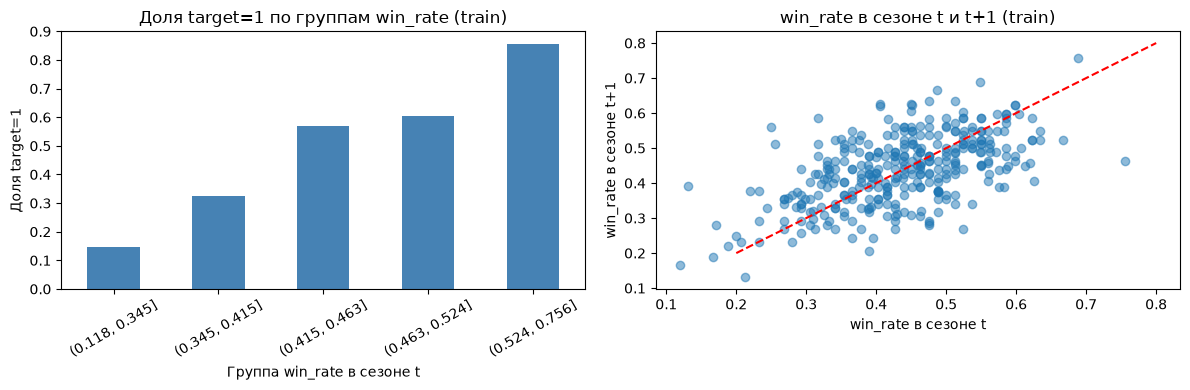

In [16]:
#график к вп1
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

summary["доля_target1"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Доля target=1 по группам win_rate (train)")
axes[0].set_xlabel("Группа win_rate в сезоне t")
axes[0].set_ylabel("Доля target=1")
axes[0].tick_params(axis="x", rotation=30)

axes[1].scatter(eda["win_rate"], eda["next_win_rate"], alpha=0.5)
axes[1].plot([0.2,0.8], [0.2, 0.8], color="red", linestyle="--")
axes[1].set_title("win_rate в сезоне t и t+1 (train)")
axes[1].set_xlabel("win_rate в сезоне t")
axes[1].set_ylabel("win_rate в сезоне t+1")

plt.tight_layout()
plt.show()

In [17]:
eda["change"] = eda["next_win_rate"] - eda["win_rate"]
cols=["team", "year", "win_rate", "next_win_rate", "next_median", "target"]

print("Сильнее всего просели:")
print(eda.sort_values("change").head(3)[cols])
print("\nСильнее всего выросли:")
print(eda.sort_values("change").tail(3)[cols])

Сильнее всего просели:
                  team  year  win_rate  next_win_rate  next_median  target
124  Detroit Red Wings  1995     0.756          0.463        0.427       1
231   Florida Panthers  1999     0.524          0.268        0.445       0
33    New York Rangers  1991     0.625          0.405        0.476       0

Сильнее всего выросли:
                 team  year  win_rate  next_win_rate  next_median  target
59    San Jose Sharks  1992     0.131          0.393        0.464       0
123      Dallas Stars  1995     0.317          0.585        0.427       1
36   Quebec Nordiques  1991     0.250          0.560        0.476       1


In [18]:
#второй вопрос
sub = eda[eda["ot_losses"].notna()].copy()

print("Пар с известным ot_losses:", len(sub), "из", len(eda))
print("Годы t с ot_losses:", sorted(sub["year"].unique()))
print("Годы t без ot_losses:", sorted(eda[eda["ot_losses"].isna()]["year"].unique()))
print("ot_losses: min, медиана, max:", sub["ot_losses"].min(), sub["ot_losses"].median(), sub["ot_losses"].max())

Пар с известным ot_losses: 118 из 338
Годы t с ot_losses: [np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002)]
Годы t без ot_losses: [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998)]
ot_losses: min, медиана, max: 0.0 4.0 9.0


In [23]:
sub["ot_group"] = pd.qcut(sub["ot_losses"], 3, duplicates="drop")

ot_summary = sub.groupby("ot_group", observed=True).agg(
    пар=("target", "size"),
    средний_ot=("ot_losses", "mean"),
    средний_win_rate=("win_rate", "mean"),
    доля_target1=("target", "mean"),
)
print(ot_summary.round(3))

print("\nКорреляция ot_losses и target:", round(sub["ot_losses"].corr(sub["target"]), 3))
print("Корреляция ot_losses и win_rate:", round(sub["ot_losses"].corr(sub["win_rate"]), 3))

               пар  средний_ot  средний_win_rate  доля_target1
ot_group                                                      
(-0.001, 3.0]   43       2.163             0.470         0.535
(3.0, 5.0]      42       4.405             0.436         0.524
(5.0, 9.0]      33       7.091             0.398         0.424

Корреляция ot_losses и target: -0.047
Корреляция ot_losses и win_rate: -0.339


In [25]:
res_ot = sub["ot_losses"] - np.polyval(np.polyfit(sub["win_rate"], sub["ot_losses"], 1), sub["win_rate"])
res_target = sub["target"] - np.polyval(np.polyfit(sub["win_rate"], sub["target"], 1), sub["win_rate"])

print("Связь ot_losses с target при учете win_rate:", round(np.corrcoef(res_ot, res_target)[0,1], 3))

Связь ot_losses с target при учете win_rate: 0.15


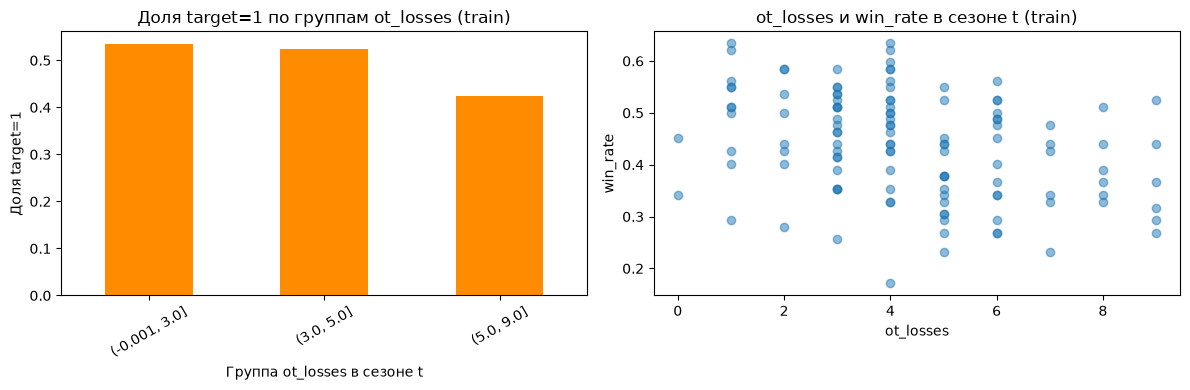

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ot_summary["доля_target1"].plot(kind="bar", ax=axes[0], color="darkorange")
axes[0].set_title("Доля target=1 по группам ot_losses (train)")
axes[0].set_xlabel("Группа ot_losses в сезоне t")
axes[0].set_ylabel("Доля target=1")
axes[0].tick_params(axis="x", rotation=30)

axes[1].scatter(sub["ot_losses"], sub["win_rate"], alpha=0.5)
axes[1].set_title("ot_losses и win_rate в сезоне t (train)")
axes[1].set_xlabel("ot_losses")
axes[1].set_ylabel("win_rate")

plt.tight_layout()
plt.show()

**Ответ 3.2:**

Вопрос 1. Все графики и сводки считал только по train (338 пар). Пары разбил на 5 равных по размеру групп по win_rate сезона t используя qcut. Доля target=1 растет от слабой группы к сильной: 0.147, 0.324, 0.569, 0.603, 0.857 (в группах 68, 74, 65, 68 и 63 пары). Корреляция win_rate в сезоне t с win_rate в сезоне t+1 равна 0.561, с target 0.477. Ожидание подтвердилось: связь положительная и умеренная. На диаграмме рассеяния облако идет вдоль красной линии "ничего не изменилось", но наклон у него более пологий: слабые команды в среднем улучшаются, сильные ухудшаются. Конкретные случаи: Detroit Red Wings в 1995 имели win_rate 0.756, а в 1996 0.463 (медиана 1996 года 0.427, поэтому target все равно 1), Dallas Stars в 1995 имели 0.317, а в 1996 0.585. Ограничения: корреляция не показывает причину, выводы по 338 парам из 1991-2003 годов и не обязательно переносятся на другие эпохи, соседние пары одной команды делят общую строку сезона, поэтому наблюдения не независимы, разбиение на 5 групп выбрано мной произвольно.

Вопрос 2. ot_losses известен только для 118 пар из 338 (t = 1999-2002), в остальных (t = 1990-1998) его нет. По трем группам ot_losses (0-3, 4-5, 6-9) доля target=1 равна 0.535, 0.524 и 0.424, а корреляция ot_losses с target всего -0.047, то есть связи почти нет. При этом ot_losses связан с win_rate (корреляция -0.339, средний win_rate по группам падает с 0.470 до 0.398), так что небольшое снижение доли, вероятнее всего, отражает более низкую долю побед, а не сам овертайм. Убрал влияние win_rate (по остаткам линейной регрессии): связь ot_losses с target осталась слабой, 0.15. Ожидание про слабую связь подтвердилось. Ограничения: 118 пар из четырех сезонов, корреляция 0.15 на такой выборке мало отличима от шума, разбиение на группы произвольное, по 1990-1998 годам вывод вообще недоступен. Из-за этого ot_losses не включаю в основную модель, а пропуски до 1999 года не заполняю.

## Раздел 4. Модели и эксперименты: 25 баллов

### 4.1. Постройте ориентиры

На train обучите простой константный baseline и оцените его на validation.
Отдельно используйте текущий `win_rate` как простую оценку для ранжирования
будущего класса. Посчитайте ROC-AUC обоих ориентиров и объясните,
какую планку задаёт каждый из них для обучаемой модели.

In [ ]:
# 4.1. Ваш код
# Добавьте ячейки при необходимости.

**Ответ 4.1:**

_Ваш ответ со ссылками на результаты собственной работы._

### 4.2. Постройте первую модель

Обучите логистическую регрессию. Самостоятельно выберите признаки и обоснуйте выбор.
Обработку пропусков и масштабирование включите в Pipeline и обучайте только на train.
Посчитайте ROC-AUC на validation и сравните с обоими ориентирами.
Объясните результат без использования test.

In [ ]:
# 4.2. Ваш код
# Добавьте ячейки при необходимости.

**Ответ 4.2:**

_Ваш ответ со ссылками на результаты собственной работы._

### 4.3. Проведите собственный эксперимент

Выберите одно осмысленное изменение: состав признаков, способ обработки данных,
параметры или другой алгоритм. До запуска запишите ожидаемый эффект и его причину.
Изменяйте одну понятную часть решения, сравните варианты на validation
и зафиксируйте выбор финальной модели до просмотра test.
Дополнительные эксперименты допустимы, но их количество само по себе не оценивается.

In [ ]:
# 4.3. Ваш код
# Добавьте ячейки при необходимости.

**Ответ 4.3:**

_Ваш ответ со ссылками на результаты собственной работы._

## Раздел 5. Итоговая оценка и анализ ошибок: 15 баллов

### 5.1. Проведите итоговую оценку

Зафиксируйте выбранную модель, признаки и параметры, затем один раз оцените её на test.
Покажите ROC-AUC, F1 и accuracy при пороге 0.5 для выбранной модели
и сопоставимых baseline. Объясните различия между метриками и сравните
результаты validation и test. После этого не меняйте выбранное решение.

In [ ]:
# 5.1. Ваш код
# Добавьте ячейки при необходимости.

**Ответ 5.1:**

_Ваш ответ со ссылками на результаты собственной работы._

### 5.2. Разберите ошибки

Выберите от трёх до пяти ошибок финальной модели по явно указанному принципу.
Это могут быть наиболее уверенные ошибки, отдельный тип ошибки или другой
обоснованный набор. Покажите идентификаторы строк, вероятности и значения,
необходимые для анализа. Найдите общие черты и различия; отделите факты
из таблицы от гипотез и назовите данные, нужные для проверки одной гипотезы.

In [ ]:
# 5.2. Ваш код
# Добавьте ячейки при необходимости.

**Ответ 5.2:**

_Ваш ответ со ссылками на результаты собственной работы._

## Раздел 6. Выводы и воспроизводимость: 5 баллов

### 6.1. Сформулируйте выводы

Сформулируйте основные выводы и ограничения работы со ссылками на свои графики,
строки и метрики. Опишите минимум два решения, которые вы изменили
или подтвердили после получения результатов. Назовите одно улучшение,
которое вы сознательно не стали выполнять, и объясните причину.
Убедитесь, что последовательность работы и финальные параметры можно воспроизвести.

In [ ]:
# 6.1. Ваш код
# Добавьте ячейки при необходимости.

**Ответ 6.1:**

_Ваш ответ со ссылками на результаты собственной работы._